In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d

class RocketFeatureExtractor:
    def __init__(self, hand="Right", target_fps=10.0, orig_fps=30.0, window_sec=20.0, step_sec=5.0):
        self.hand = hand
        self.target_fps = float(target_fps)
        self.orig_fps = float(orig_fps)
        self.dt_target = 1.0 / self.target_fps
        self.dt_orig = 1.0 / self.orig_fps
        self.window_size = int(window_sec * self.target_fps)  # e.g., 200 for 20s at 10 FPS
        self.step_size = int(step_sec * self.target_fps)

    def _calculate_4_channels(self, dfh):
        # --- 1. Re-index to a strict 30 FPS timeline to expose gaps ---
        min_f, max_f = dfh['frame'].min(), dfh['frame'].max()
        # Create a full index: if frame 10 is followed by frame 50, frames 11-49 will be NaN
        full_idx = np.arange(min_f, max_f + 1)
        df_gap = dfh.set_index('frame').reindex(full_idx).reset_index()

        def get_pts(lm_prefix):
            cols = [f'{lm_prefix}_{ax}_smooth' for ax in ['x', 'y']]
            # We ffill/bfill ONLY for the derivative math so it doesn't break,
            # but we will mask these out later.
            return df_gap[cols].ffill().bfill().fillna(0).values

        pts0 = get_pts('lm_0')   # Wrist
        pts5 = get_pts('lm_5')   # Index
        pts17 = get_pts('lm_17') # Pinky

        # --- 2. Calculate Kinematics at 30 FPS ---
        d_pos = np.diff(pts0, axis=0, prepend=pts0[:1, :])
        v_mag = np.sqrt(np.sum(d_pos**2, axis=1)) / self.dt_orig
        vx = d_pos[:, 0] / self.dt_orig
        vy = d_pos[:, 1] / self.dt_orig
        #v_theta = np.arctan2(d_pos[:, 1], d_pos[:, 0])

        v_orient = pts5 - pts0
        angles = np.arctan2(v_orient[:, 1], v_orient[:, 0])
        d_angle = np.diff(angles, prepend=angles[0])
        d_angle = (d_angle + np.pi) % (2 * np.pi) - np.pi

        v1, v2 = pts5 - pts0, pts17 - pts0
        palm_area = 0.5 * np.abs(v1[:, 0]*v2[:, 1] - v1[:, 1]*v2[:, 0])

        # --- 3. Create Validity Mask (at 30 FPS) ---
        # A frame is valid ONLY if it existed in the original tracking AND landmarks were present
        mask_30 = ~(df_gap['lm_0_x_smooth'].isna() | 
                    df_gap['lm_5_x_smooth'].isna() | 
                    df_gap['lm_17_x_smooth'].isna()).values

        # --- 4. Downsample to 10 FPS ---
        # Instead of slicing [::3], we use a mean resample to be more robust
        channels_30 = np.stack([v_mag, vx, vy, d_angle, palm_area], axis=1)
        
        # Determine number of 10fps steps
        n_steps_10 = int(len(channels_30) * (self.target_fps / self.orig_fps))
        
        # Resample channels and mask to 10 FPS
        x_30 = np.linspace(0, 1, len(channels_30))
        x_10 = np.linspace(0, 1, n_steps_10)
        
        f_chan = interp1d(x_30, channels_30, axis=0, kind='linear', fill_value="extrapolate")
        f_mask = interp1d(x_30, mask_30.astype(float), kind='nearest', fill_value="extrapolate")
        
        channels_10 = f_chan(x_10)
        mask_10 = f_mask(x_10) > 0.5 # Back to boolean

        # --- 5. Apply Mask ---
        # Crucial: Large gaps become zeros. ROCKET kernels will see "flat" 
        # periods where tracking was lost, preserving the temporal duration.
        return channels_10 * mask_10[:, np.newaxis]

    def prepare_rocket_windows(self, df_dict):
        all_windows = []
        video_mapping = [] # To know which window belongs to which video

        for key, df in tqdm(df_dict.items(), desc="Slicing ROCKET Windows"):
            dfh = df[df["hand_label"] == self.hand].copy()
            if len(dfh) < self.window_size: continue
            
            # 1. Get constant 10 FPS channels (using the Gap-Aware logic from before)
            # This returns (T_total, 4) at a fixed 10 FPS
            full_signal = self._calculate_4_channels(dfh) 
            
            # 2. Slice into fixed-size windows
            # No interpolation needed here! Physical units are preserved.
            for start in range(0, len(full_signal) - self.window_size + 1, self.step_size):
                end = start + self.window_size
                window = full_signal[start:end] # (200, 4)
                
                # ROCKET expects (Channels, Time)
                all_windows.append(window.T)
                video_mapping.append(key)
        
        return np.array(all_windows), video_mapping

In [2]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

In [3]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:03<00:00, 25.23it/s]


In [4]:
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeCV

# 1. Initialize and Prepare Data
extractor = RocketFeatureExtractor(hand="Right", window_sec=3.0, step_sec=1.0)
X_windows, video_mapping = extractor.prepare_rocket_windows(df_dict)

# 2. Generate ROCKET Features (The "Brute Force" part)
# This will turn your 5 channels into ~10,000 features
rocket = MiniRocketMultivariate(random_state=40)
X_win_feats = rocket.fit_transform(X_windows)

# 3. Predict Residuals
# Let's say 'df_results' contains your MAE 5.0 predictions
# residuals = actual_scores - predicted_scores

# Merge ROCKET features with your residual labels using 'keys'
# and run a Ridge Regression. 
# If the R2 score is > 0.1, you have found a local signal!

Slicing ROCKET Windows: 100%|██████████| 83/83 [00:02<00:00, 37.86it/s]
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [5]:
df_rocket = pd.DataFrame(X_win_feats)
df_rocket['video_key'] = video_mapping
video_level_rocket = df_rocket.groupby('video_key').mean()

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

n = 30
# --- 1. Distill ROCKET Features ---
# We use PCA because 10,000 features on 83 samples is "Overfitting Suicide"
pca_rocket = PCA(n_components=n) # Keep top 15 temporal patterns
rocket_pca_features = pca_rocket.fit_transform(StandardScaler().fit_transform(video_level_rocket))

# Convert to DataFrame for merging
df_rocket_pca = pd.DataFrame(
    rocket_pca_features, 
    index=video_level_rocket.index, 
    columns=[f'Rocket_PC{i+1}' for i in range(n)]
)

In [7]:
df_rocket_pca = df_rocket_pca.reset_index()

In [8]:
# load 
df_metrics = pd.read_csv("data/metrics/best_global_metrics.csv")
df_metrics.head()



,Participant Number,GRS_Total,QRS_Overal,Case_Number,adjusted_total_path_Right,total_duration_Right,num_reversals_Right,velocity_corr
0,1,59.25,48.50,1,62034.389107,534.933333,737,0.300569
1,1,54.40,45.00,2,37353.044239,288.033333,378,0.642479
2,1,74.50,60.50,3,51364.691660,423.033333,694,0.476772
3,2,49.25,39.25,1,103592.752300,1281.533333,1571,0.356040
4,2,49.00,38.00,2,74343.087367,1010.833333,1133,0.475344


In [9]:
df_combined = pd.merge(df_rocket_pca, df_metrics, left_index=True, right_index=True)

In [10]:

global_features = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
rocket_features = [f'Rocket_PC{i+1}' for i in range(n)]

# for each of the features correlation with QRS_Overal
for feature in global_features + rocket_features:
    corr = df_combined[feature].corr(df_combined['QRS_Overal'])
    print(f"Correlation between {feature} and QRS_Overal: {corr:.4f}")

Correlation between adjusted_total_path_Right and QRS_Overal: -0.7176
Correlation between total_duration_Right and QRS_Overal: -0.6843
Correlation between num_reversals_Right and QRS_Overal: -0.7203
Correlation between velocity_corr and QRS_Overal: -0.0071
Correlation between Rocket_PC1 and QRS_Overal: 0.0304
Correlation between Rocket_PC2 and QRS_Overal: -0.3746
Correlation between Rocket_PC3 and QRS_Overal: 0.0793
Correlation between Rocket_PC4 and QRS_Overal: 0.2099
Correlation between Rocket_PC5 and QRS_Overal: -0.0201
Correlation between Rocket_PC6 and QRS_Overal: 0.2554
Correlation between Rocket_PC7 and QRS_Overal: 0.1660
Correlation between Rocket_PC8 and QRS_Overal: 0.2059
Correlation between Rocket_PC9 and QRS_Overal: -0.0276
Correlation between Rocket_PC10 and QRS_Overal: 0.0865
Correlation between Rocket_PC11 and QRS_Overal: -0.1954
Correlation between Rocket_PC12 and QRS_Overal: -0.3518
Correlation between Rocket_PC13 and QRS_Overal: 0.0444
Correlation between Rocket_PC14 

In [11]:
df_combined[rocket_features].describe()

,Rocket_PC1,Rocket_PC2,Rocket_PC3,Rocket_PC4,Rocket_PC5,Rocket_PC6,Rocket_PC7,Rocket_PC8,Rocket_PC9,Rocket_PC10,...,Rocket_PC21,Rocket_PC22,Rocket_PC23,Rocket_PC24,Rocket_PC25,Rocket_PC26,Rocket_PC27,Rocket_PC28,Rocket_PC29,Rocket_PC30
count,83.000000,83.000000,8.300000e+01,8.300000e+01,83.000000,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,...,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01
mean,-0.000001,-0.000001,5.515225e-07,7.640884e-07,0.000001,-9.192041e-08,-4.251319e-07,-6.894031e-08,4.136419e-07,2.527811e-07,...,-9.192041e-08,-1.378806e-07,-2.556536e-07,-1.723508e-08,2.298010e-07,-6.463154e-09,-1.091555e-07,1.464982e-07,1.723508e-08,-6.175903e-08
std,76.079521,43.036648,3.462226e+01,1.607108e+01,14.232477,1.093544e+01,8.981326e+00,8.475034e+00,7.151639e+00,6.383373e+00,...,3.518193e+00,3.437137e+00,3.326627e+00,3.042337e+00,3.022302e+00,2.839793e+00,2.822569e+00,2.687639e+00,2.604032e+00,2.533755e+00
min,-139.747543,-129.171982,-6.506416e+01,-3.543555e+01,-33.345184,-3.033388e+01,-2.522666e+01,-2.326809e+01,-1.632318e+01,-1.349567e+01,...,-7.463760e+00,-7.976614e+00,-8.276940e+00,-7.005424e+00,-7.932119e+00,-7.474919e+00,-8.405046e+00,-6.725149e+00,-6.507384e+00,-8.116443e+00
25%,-59.066446,-26.794439,-2.432295e+01,-8.766038e+00,-10.373924,-6.387051e+00,-5.935146e+00,-5.807974e+00,-3.920064e+00,-3.131233e+00,...,-2.448281e+00,-2.159930e+00,-1.828223e+00,-1.785292e+00,-2.264160e+00,-1.711729e+00,-1.982969e+00,-1.673245e+00,-1.645283e+00,-1.749729e+00
50%,-0.030668,4.521749,-1.535337e+00,1.407596e-01,-2.217853,-1.353677e+00,-5.222832e-01,-2.843632e-01,-2.414702e-01,-6.777078e-01,...,-8.000737e-02,-2.004651e-01,-1.263803e-01,1.227949e-01,-3.475238e-01,3.007513e-01,3.175177e-01,-1.960866e-01,-2.492656e-01,5.535103e-02
75%,48.194723,28.552475,2.744020e+01,8.895119e+00,8.335180,7.229955e+00,4.743577e+00,5.219088e+00,4.729298e+00,3.506042e+00,...,2.202389e+00,1.897772e+00,1.892687e+00,1.586897e+00,2.529532e+00,2.055416e+00,1.716725e+00,1.587235e+00,1.607880e+00,1.996575e+00
max,175.944336,86.340622,8.157663e+01,3.430707e+01,32.567020,2.675718e+01,2.811970e+01,2.472068e+01,2.033789e+01,1.788504e+01,...,1.193604e+01,8.987816e+00,9.835169e+00,8.219657e+00,6.368824e+00,5.878791e+00,7.526058e+00,6.411886e+00,7.518404e+00,5.460006e+00


--- Correlation with Residuals (Base: adjusted_total_path_Right) ---
        Feature  Resid_Corr   p-value
23  Rocket_PC24    0.344027  0.001450
22  Rocket_PC23    0.134108  0.226769
6    Rocket_PC7    0.130187  0.240767
5    Rocket_PC6    0.129113  0.244703
15  Rocket_PC16    0.125755  0.257295
21  Rocket_PC22    0.115314  0.299223
17  Rocket_PC18    0.093085  0.402592
26  Rocket_PC27    0.052039  0.640339
3    Rocket_PC4    0.041779  0.707650
9   Rocket_PC10    0.035340  0.751107
29  Rocket_PC30    0.031301  0.778778
27  Rocket_PC28    0.030382  0.785119
4    Rocket_PC5    0.008975  0.935820
2    Rocket_PC3    0.007912  0.943407
19  Rocket_PC20   -0.011044  0.921061
10  Rocket_PC11   -0.022474  0.840175
8    Rocket_PC9   -0.032876  0.767953
12  Rocket_PC13   -0.033555  0.763302
7    Rocket_PC8   -0.035190  0.752127
16  Rocket_PC17   -0.059004  0.596210
13  Rocket_PC14   -0.059596  0.592521
20  Rocket_PC21   -0.077223  0.487743
28  Rocket_PC29   -0.077562  0.485831
24  Rocket_PC25   -

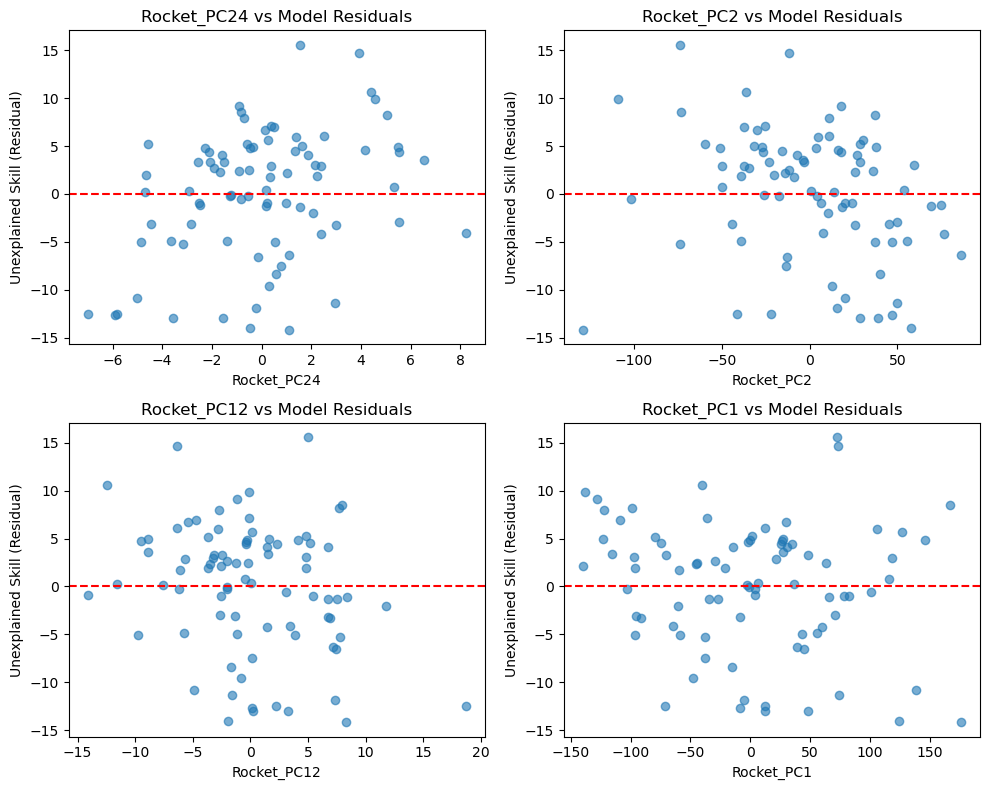

In [12]:
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr
from matplotlib import pyplot as plt

def residual_analysis(df, base_feature, candidate_features, target='QRS_Overal'):
    """
    Analyzes if candidate features explain the variance that the base_feature misses.
    """
    df_clean = df.copy().dropna(subset=[base_feature, target] + candidate_features)
    
    # 1. Train Base Model (Translational only)
    # We use LOSO (Leave-One-Subject-Out) to get 'fair' residuals
    participants = df_clean['Participant Number'].unique()
    df_clean['base_residuals'] = 0.0
    
    for p in participants:
        train = df_clean[df_clean['Participant Number'] != p]
        test = df_clean[df_clean['Participant Number'] == p]
        
        # Simple Linear Regression (or Ridge) for the base model
        X_train = train[[base_feature]]
        y_train = train[target]
        
        model = Ridge(alpha=0.5)
        model.fit(X_train, y_train)
        
        # Calculate Residuals: (Actual - Predicted)
        # Positive residual means the surgeon performed better than their path length suggests
        # Negative residual means they were worse than their path length suggests
        preds = model.predict(test[[base_feature]])
        df_clean.loc[test.index, 'base_residuals'] = test[target].values - preds

    # 2. Correlate New Features with the Residuals
    print(f"--- Correlation with Residuals (Base: {base_feature}) ---")
    results = []
    for feat in candidate_features:
        r, p = pearsonr(df_clean[feat], df_clean['base_residuals'])
        results.append({'Feature': feat, 'Resid_Corr': r, 'p-value': p})
    
    res_df = pd.DataFrame(results).sort_values('Resid_Corr', ascending=False)
    print(res_df)

    top_feats = res_df.sort_values('Resid_Corr', key=lambda x: x.abs(), ascending=False).head(4)['Feature'].tolist()
    
    # 3. Visualization
    plt.figure(figsize=(10, 8))
    for i, feat in enumerate(top_feats): # Plot top 2
        plt.subplot(2, 2, i+1)
        plt.scatter(df_clean[feat], df_clean['base_residuals'], alpha=0.6)
        plt.axhline(0, color='red', linestyle='--')
        plt.title(f"{feat} vs Model Residuals")
        plt.xlabel(feat)
        plt.ylabel("Unexplained Skill (Residual)")
    plt.tight_layout()
    plt.show()
    
    return res_df

# Example Usage:

analysis_results = residual_analysis(df_combined, 'adjusted_total_path_Right', rocket_features)

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 184.45it/s]


          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7928
Overall MAE: 4.6354
Overall Std Dev of Errors: 3.5864

--- Per-Fold Performance Summary ---
           Train_MAE  Test_MAE  Test_Corr
SurgeonID                                
1           4.237345  5.632131   0.633140
2           4.249771  4.339864   0.813831
3           4.297976  4.763264  -0.220119
4           4.191341  6.311115  -0.609646
5           4.095413  8.592588   0.661087
6           4.362803  2.271418   0.760275
7           4.171906  6.999769  -0.257632
9           4.237275  6.382155  -0.815719
10          4.371966  2.394328   0.986179
11          4.314654  3.729405   0.926657
12          4.301304  3.912272  -0.892245
13          4.354493  2.067007   0.825682
14          4.196018  7.468356  -0.975770
15          4.268542  5.470146  -0.246582
16          4.152869  9.205877  -0.459934
17          4.296881  3.441300   0.652803
18          4.285201  3.758673   0.941829
19          4.235017  5.467552 

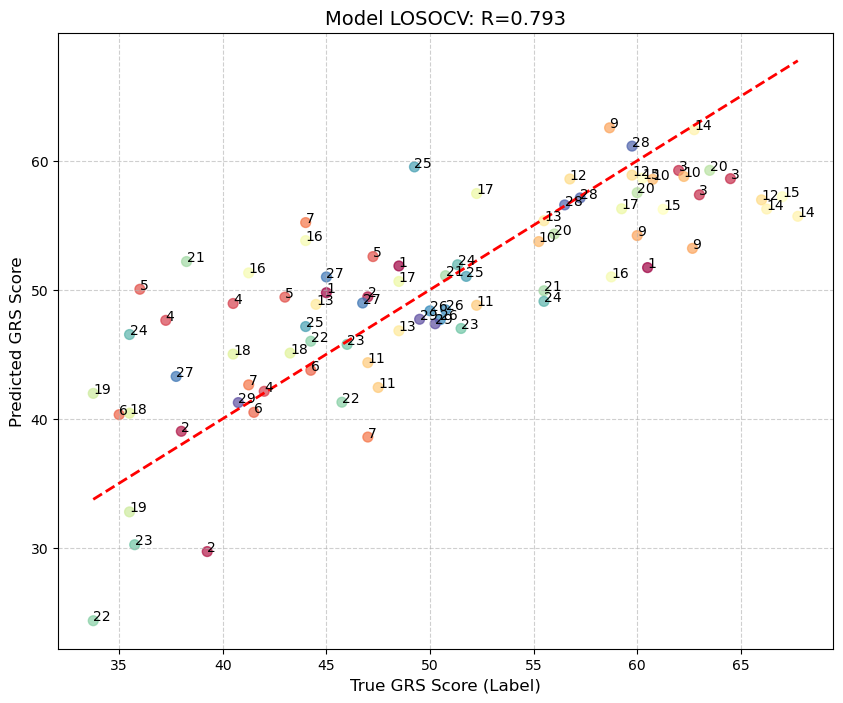

In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and correctly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']]
additional_feature_cols = ['Rocket_PC12', 'Rocket_PC24']  # 'Rocket_PC25', 'Rocket_PC21', 'Rocket_PC22'
all_feature_cols = feature_cols + additional_feature_cols
X = df_combined[all_feature_cols].values
y = df_combined['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = df_combined['Participant Number'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    
    # PCA but only on feature_cols
    pca = PCA(n_components=min(3, len(feature_cols)))  # Adjust number of components as needed
    X_train_pca = pca.fit_transform(X_train[:, :len(feature_cols)])
    X_test_pca = pca.transform(X_test[:, :len(feature_cols)])
    
    # component list to keep
    component_list = [0,1,2]  # Keep only the first principal component
    X_train_pca = X_train_pca[:, component_list]
    X_test_pca = X_test_pca[:, component_list]
    
    # Combine PCA features with additional features
    X_train = np.hstack((X_train_pca, X_train[:, len(feature_cols):]))
    X_test = np.hstack((X_test_pca, X_test[:, len(feature_cols):]))

    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5) 
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Model LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()